In [1]:

# imports
import os
import sys
import types
import json
import base64

# figure size/format
fig_width = 7
fig_height = 5
fig_format = 'retina'
fig_dpi = 96
interactivity = ''
is_shiny = False
is_dashboard = False
plotly_connected = True

# matplotlib defaults / format
try:
  import matplotlib.pyplot as plt
  plt.rcParams['figure.figsize'] = (fig_width, fig_height)
  plt.rcParams['figure.dpi'] = fig_dpi
  plt.rcParams['savefig.dpi'] = "figure"

  # IPython 7.14 deprecated set_matplotlib_formats from IPython
  try:
    from matplotlib_inline.backend_inline import set_matplotlib_formats
  except ImportError:
    # Fall back to deprecated location for older IPython versions
    from IPython.display import set_matplotlib_formats
    
  set_matplotlib_formats(fig_format)
except Exception:
  pass

# plotly use connected mode
try:
  import plotly.io as pio
  if plotly_connected:
    pio.renderers.default = "notebook_connected"
  else:
    pio.renderers.default = "notebook"
  for template in pio.templates.keys():
    pio.templates[template].layout.margin = dict(t=30,r=0,b=0,l=0)
except Exception:
  pass

# disable itables paging for dashboards
if is_dashboard:
  try:
    from itables import options
    options.dom = 'fiBrtlp'
    options.maxBytes = 1024 * 1024
    options.language = dict(info = "Showing _TOTAL_ entries")
    options.classes = "display nowrap compact"
    options.paging = False
    options.searching = True
    options.ordering = True
    options.info = True
    options.lengthChange = False
    options.autoWidth = False
    options.responsive = True
    options.keys = True
    options.buttons = []
  except Exception:
    pass
  
  try:
    import altair as alt
    # By default, dashboards will have container sized
    # vega visualizations which allows them to flow reasonably
    theme_sentinel = '_quarto-dashboard-internal'
    def make_theme(name):
        nonTheme = alt.themes._plugins[name]    
        def patch_theme(*args, **kwargs):
            existingTheme = nonTheme()
            if 'height' not in existingTheme:
              existingTheme['height'] = 'container'
            if 'width' not in existingTheme:
              existingTheme['width'] = 'container'

            if 'config' not in existingTheme:
              existingTheme['config'] = dict()
            
            # Configure the default font sizes
            title_font_size = 15
            header_font_size = 13
            axis_font_size = 12
            legend_font_size = 12
            mark_font_size = 12
            tooltip = False

            config = existingTheme['config']

            # The Axis
            if 'axis' not in config:
              config['axis'] = dict()
            axis = config['axis']
            if 'labelFontSize' not in axis:
              axis['labelFontSize'] = axis_font_size
            if 'titleFontSize' not in axis:
              axis['titleFontSize'] = axis_font_size  

            # The legend
            if 'legend' not in config:
              config['legend'] = dict()
            legend = config['legend']
            if 'labelFontSize' not in legend:
              legend['labelFontSize'] = legend_font_size
            if 'titleFontSize' not in legend:
              legend['titleFontSize'] = legend_font_size  

            # The header
            if 'header' not in config:
              config['header'] = dict()
            header = config['header']
            if 'labelFontSize' not in header:
              header['labelFontSize'] = header_font_size
            if 'titleFontSize' not in header:
              header['titleFontSize'] = header_font_size    

            # Title
            if 'title' not in config:
              config['title'] = dict()
            title = config['title']
            if 'fontSize' not in title:
              title['fontSize'] = title_font_size

            # Marks
            if 'mark' not in config:
              config['mark'] = dict()
            mark = config['mark']
            if 'fontSize' not in mark:
              mark['fontSize'] = mark_font_size

            # Mark tooltips
            if tooltip and 'tooltip' not in mark:
              mark['tooltip'] = dict(content="encoding")

            return existingTheme
            
        return patch_theme

    # We can only do this once per session
    if theme_sentinel not in alt.themes.names():
      for name in alt.themes.names():
        alt.themes.register(name, make_theme(name))
      
      # register a sentinel theme so we only do this once
      alt.themes.register(theme_sentinel, make_theme('default'))
      alt.themes.enable('default')

  except Exception:
    pass

# enable pandas latex repr when targeting pdfs
try:
  import pandas as pd
  if fig_format == 'pdf':
    pd.set_option('display.latex.repr', True)
except Exception:
  pass

# interactivity
if interactivity:
  from IPython.core.interactiveshell import InteractiveShell
  InteractiveShell.ast_node_interactivity = interactivity

# NOTE: the kernel_deps code is repeated in the cleanup.py file
# (we can't easily share this code b/c of the way it is run).
# If you edit this code also edit the same code in cleanup.py!

# output kernel dependencies
kernel_deps = dict()
for module in list(sys.modules.values()):
  # Some modules play games with sys.modules (e.g. email/__init__.py
  # in the standard library), and occasionally this can cause strange
  # failures in getattr.  Just ignore anything that's not an ordinary
  # module.
  if not isinstance(module, types.ModuleType):
    continue
  path = getattr(module, "__file__", None)
  if not path:
    continue
  if path.endswith(".pyc") or path.endswith(".pyo"):
    path = path[:-1]
  if not os.path.exists(path):
    continue
  kernel_deps[path] = os.stat(path).st_mtime
print(json.dumps(kernel_deps))

# set run_path if requested
run_path = 'QzpcVXNlcnNcbG9pY2hcRG9jdW1lbnRzXFdvcmtcR2l0aHViXHF1YXJ0b1xweXRob25faWFfcXVhcnRvXG1vZHVsZXNcbW9kdWxlXzAz'
if run_path:
  # hex-decode the path
  run_path = base64.b64decode(run_path.encode("utf-8")).decode("utf-8")
  os.chdir(run_path)

# reset state
%reset

# shiny
# Checking for shiny by using False directly because we're after the %reset. We don't want
# to set a variable that stays in global scope.
if False:
  try:
    import htmltools as _htmltools
    import ast as _ast

    _htmltools.html_dependency_render_mode = "json"

    # This decorator will be added to all function definitions
    def _display_if_has_repr_html(x):
      try:
        # IPython 7.14 preferred import
        from IPython.display import display, HTML
      except:
        from IPython.core.display import display, HTML

      if hasattr(x, '_repr_html_'):
        display(HTML(x._repr_html_()))
      return x

    # ideally we would undo the call to ast_transformers.append
    # at the end of this block whenver an error occurs, we do 
    # this for now as it will only be a problem if the user 
    # switches from shiny to not-shiny mode (and even then likely
    # won't matter)
    import builtins
    builtins._display_if_has_repr_html = _display_if_has_repr_html

    class _FunctionDefReprHtml(_ast.NodeTransformer):
      def visit_FunctionDef(self, node):
        node.decorator_list.insert(
          0,
          _ast.Name(id="_display_if_has_repr_html", ctx=_ast.Load())
        )
        return node

      def visit_AsyncFunctionDef(self, node):
        node.decorator_list.insert(
          0,
          _ast.Name(id="_display_if_has_repr_html", ctx=_ast.Load())
        )
        return node

    ip = get_ipython()
    ip.ast_transformers.append(_FunctionDefReprHtml())

  except:
    pass

def ojs_define(**kwargs):
  import json
  try:
    # IPython 7.14 preferred import
    from IPython.display import display, HTML
  except:
    from IPython.core.display import display, HTML

  # do some minor magic for convenience when handling pandas
  # dataframes
  def convert(v):
    try:
      import pandas as pd
    except ModuleNotFoundError: # don't do the magic when pandas is not available
      return v
    if type(v) == pd.Series:
      v = pd.DataFrame(v)
    if type(v) == pd.DataFrame:
      j = json.loads(v.T.to_json(orient='split'))
      return dict((k,v) for (k,v) in zip(j["index"], j["data"]))
    else:
      return v

  v = dict(contents=list(dict(name=key, value=convert(value)) for (key, value) in kwargs.items()))
  display(HTML('<script type="ojs-define">' + json.dumps(v) + '</script>'), metadata=dict(ojs_define = True))
globals()["ojs_define"] = ojs_define
globals()["__spec__"] = None

{"C:\\Users\\loich\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\importlib\\_bootstrap.py": 1727748220.0, "C:\\Users\\loich\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\importlib\\_bootstrap_external.py": 1727748220.0, "C:\\Users\\loich\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\zipimport.py": 1727748220.0, "C:\\Users\\loich\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\codecs.py": 1727748220.0, "C:\\Users\\loich\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\encodings\\aliases.py": 1727748220.0, "C:\\Users\\loich\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\encodings\\__init__.py": 1727748220.0, "C:\\Users\\loich\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\encodings\\utf_8.py": 1727748220.0, "C:\\Users\\loich\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\encodings\\cp1252.py": 1727748220.0, "C:\\Users\\loich\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\abc.py": 1727748220.0, "C:\\Users\\loich\\AppData\\Local\\Programs\\Python\\Python

In [2]:
#| label: setup
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pandas.api.types import CategoricalDtype
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)
pd.set_option('display.max_columns', 20)

print("✅ Environnement prêt")

✅ Environnement prêt


In [3]:
#| echo: false
# Chargement silencieux pour le rendu
df = pd.read_csv("ressources_tp/employes_rh.csv")
print(f"Dataset chargé : {df.shape}")

Dataset chargé : (1505, 17)


In [4]:
#| eval: false
# Charger le dataset
df = pd.read_csv("ressources_tp/employes_rh.csv")
print(f"Dataset chargé : {df.shape}")

In [5]:
#| eval: false
# TODO: Étape 1.1

In [6]:
print(f"Dimensions : {df.shape}")
df.head()

Dimensions : (1505, 17)


,id_employe,nom_complet,age,genre,departement,niveau_etudes,anciennete_annees,distance_km,salaire_mensuel,heures_supp_semaine,satisfaction,nb_formations,teletravail_jours,date_embauche,matricule_interne,pays,attrition
0,EMP00001,Alice Leroy,54,F,Production,Master,10.8,15.8,4301.0,0.6,Neutre,1,0,2014-03-17,92260,France,0
1,EMP00002,Inès Simon,45,M,IT,Bac,5.3,32.3,1981.0,4.1,Neutre,1,0,2019-09-15,38817,France,0
2,EMP00003,Quentin Roux,35,M,Ventes,Doctorat,0.6,14.2,4844.0,1.8,Neutre,3,0,2024-05-26,65551,France,0
3,EMP00004,Alice Bernard,36,M,R&D,Master,3.5,12.4,3032.0,1.6,Très satisfait,2,2,2021-07-03,92816,France,0
4,EMP00005,Alice Dubois,47,M,Production,Bac,4.9,9.7,2199.0,4.3,Neutre,1,3,2020-02-08,20815,France,0


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1505 entries, 0 to 1504
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id_employe           1505 non-null   str    
 1   nom_complet          1505 non-null   str    
 2   age                  1505 non-null   int64  
 3   genre                1505 non-null   str    
 4   departement          1505 non-null   str    
 5   niveau_etudes        1505 non-null   str    
 6   anciennete_annees    1505 non-null   float64
 7   distance_km          1475 non-null   float64
 8   salaire_mensuel      1456 non-null   float64
 9   heures_supp_semaine  1505 non-null   float64
 10  satisfaction         1460 non-null   str    
 11  nb_formations        1505 non-null   int64  
 12  teletravail_jours    1505 non-null   int64  
 13  date_embauche        1505 non-null   str    
 14  matricule_interne    1505 non-null   int64  
 15  pays                 1505 non-null   str    
 16 

In [8]:
df.dtypes

id_employe                 str
nom_complet                str
age                      int64
genre                      str
departement                str
niveau_etudes              str
anciennete_annees      float64
distance_km            float64
salaire_mensuel        float64
heures_supp_semaine    float64
satisfaction               str
nb_formations            int64
teletravail_jours        int64
date_embauche              str
matricule_interne        int64
pays                       str
attrition                int64
dtype: object

In [9]:
#| eval: false
# TODO: Étape 1.2 — audit typologique

In [10]:
#| eval: false
# TODO: Étape 1.3 — diagnostic

In [11]:
def diagnostiquer(df):
    """Diagnostic complet d'un DataFrame."""
    print(f"📊 {df.shape[0]:,} lignes × {df.shape[1]} colonnes")
    print(f"\n🔁 Doublons parfaits : {df.duplicated().sum()}")
    
    # NaN
    nan = df.isna().sum()
    nan = nan[nan > 0].sort_values(ascending=False)
    if len(nan) > 0:
        print(f"\n🕳️  Valeurs manquantes :")
        for col, n in nan.items():
            pct = n / len(df) * 100
            print(f"  {col:25s} : {n:4d} ({pct:.2f}%)")
    
    # Colonnes constantes
    const = [c for c in df.columns if df[c].nunique(dropna=False) <= 1]
    if const:
        print(f"\n📌 Colonnes constantes : {const}")

diagnostiquer(df)

📊 1,505 lignes × 17 colonnes

🔁 Doublons parfaits : 5

🕳️  Valeurs manquantes :
  salaire_mensuel           :   49 (3.26%)
  satisfaction              :   45 (2.99%)
  distance_km               :   30 (1.99%)

📌 Colonnes constantes : ['pays']


In [12]:
# Répartition cible
print("=== Répartition de l'attrition ===")
print(df["attrition"].value_counts())
print(f"\nTaux d'attrition : {df['attrition'].mean() * 100:.1f}%")

=== Répartition de l'attrition ===
attrition
0    1343
1     162
Name: count, dtype: int64

Taux d'attrition : 10.8%


In [13]:
#| eval: false
# TODO: Étape 2.1

In [14]:
# Stats
for col in ["salaire_mensuel", "age", "anciennete_annees"]:
    x = df[col].dropna()
    print(f"=== {col} ===")
    print(f"  Moyenne    : {x.mean():.2f}")
    print(f"  Médiane    : {x.median():.2f}")
    print(f"  Écart-type : {x.std():.2f}")
    print(f"  Skewness   : {x.skew():.3f}")
    print(f"  Min / Max  : {x.min():.1f} / {x.max():.1f}")
    print()

=== salaire_mensuel ===
  Moyenne    : 3167.85
  Médiane    : 2988.00
  Écart-type : 1731.57
  Skewness   : 15.031
  Min / Max  : 1569.0 / 47660.0

=== age ===
  Moyenne    : 37.64
  Médiane    : 38.00
  Écart-type : 9.84
  Skewness   : 0.147
  Min / Max  : 18.0 / 65.0

=== anciennete_annees ===
  Moyenne    : 5.06
  Médiane    : 3.50
  Écart-type : 5.03
  Skewness   : 1.912
  Min / Max  : -1.0 / 35.0



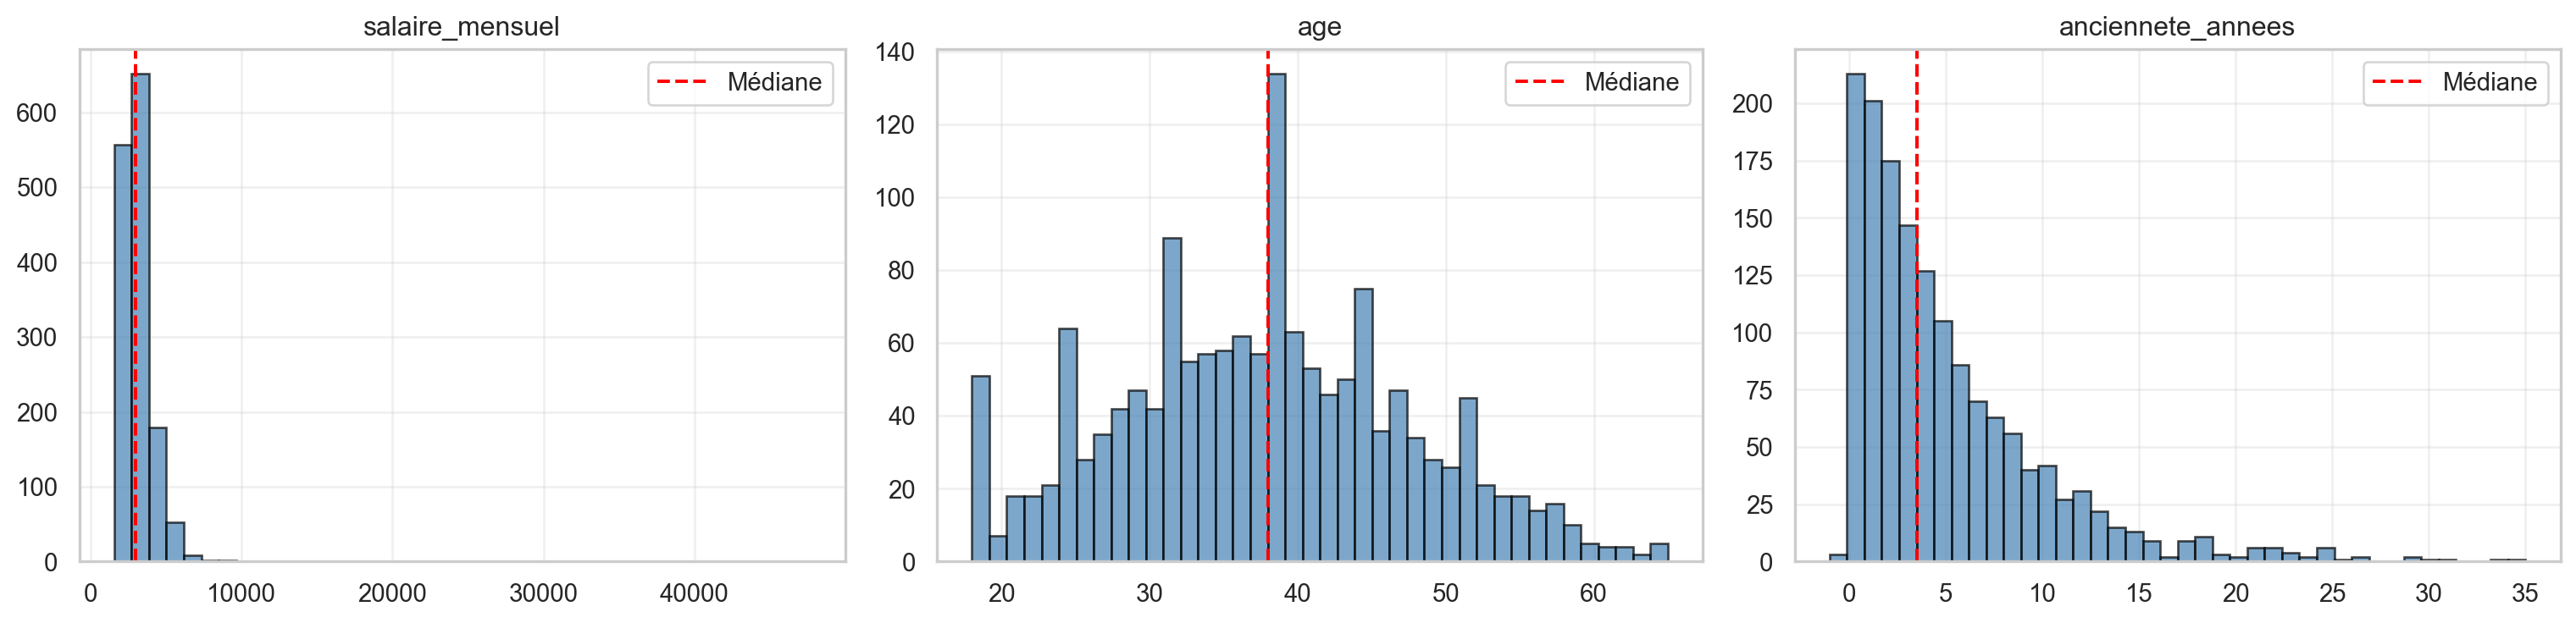

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, col in zip(axes, ["salaire_mensuel", "age", "anciennete_annees"]):
    ax.hist(df[col].dropna(), bins=40, color="steelblue", edgecolor="black", alpha=0.7)
    ax.set_title(col)
    ax.axvline(df[col].median(), color="red", linestyle="--", label="Médiane")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [16]:
#| eval: false
# TODO: Étape 2.2

In [17]:
# 1. Quanti vs cible
cols_quanti = ["heures_supp_semaine", "distance_km", "anciennete_annees", "salaire_mensuel"]
compar = df.groupby("attrition")[cols_quanti].mean().round(2)
print("=== Moyennes par groupe ===")
print(compar.T)

=== Moyennes par groupe ===
attrition                  0        1
heures_supp_semaine     3.81     4.98
distance_km            15.49    18.60
anciennete_annees       5.20     3.91
salaire_mensuel      3170.36  3147.36


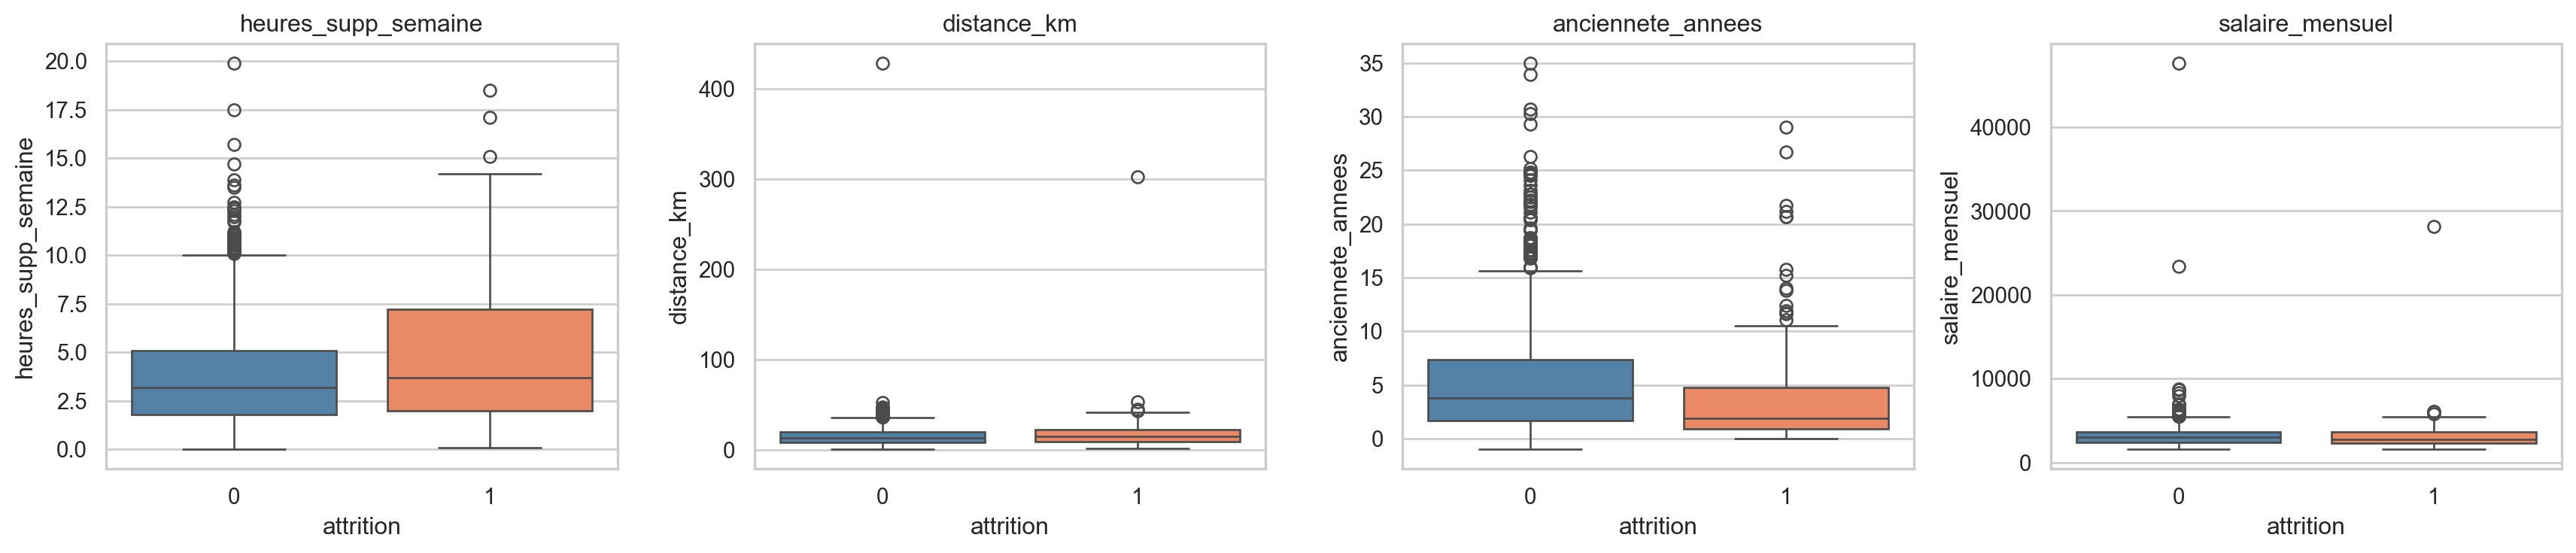

In [18]:
# Visualisation avec boxplots
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ax, col in zip(axes, cols_quanti):
    sns.boxplot(data=df, x="attrition", y=col, ax=ax, 
                hue="attrition", legend=False, palette=["steelblue", "coral"])
    ax.set_title(col)

plt.tight_layout()
plt.show()

In [19]:
# 2. Quali vs cible : taux d'attrition
for col in ["departement", "niveau_etudes"]:
    taux = df.groupby(col)["attrition"].mean().sort_values(ascending=False) * 100
    print(f"\n=== Taux d'attrition par {col} ===")
    print(taux.round(1).to_string())


=== Taux d'attrition par departement ===
departement
RH            12.5
Ventes        11.9
Production    10.9
R&D           10.1
Marketing     10.1
IT             8.3

=== Taux d'attrition par niveau_etudes ===
niveau_etudes
Doctorat    14.5
Bac         13.8
Licence     10.0
Master       9.5


In [20]:
#| eval: false
# TODO: Étape 2.3

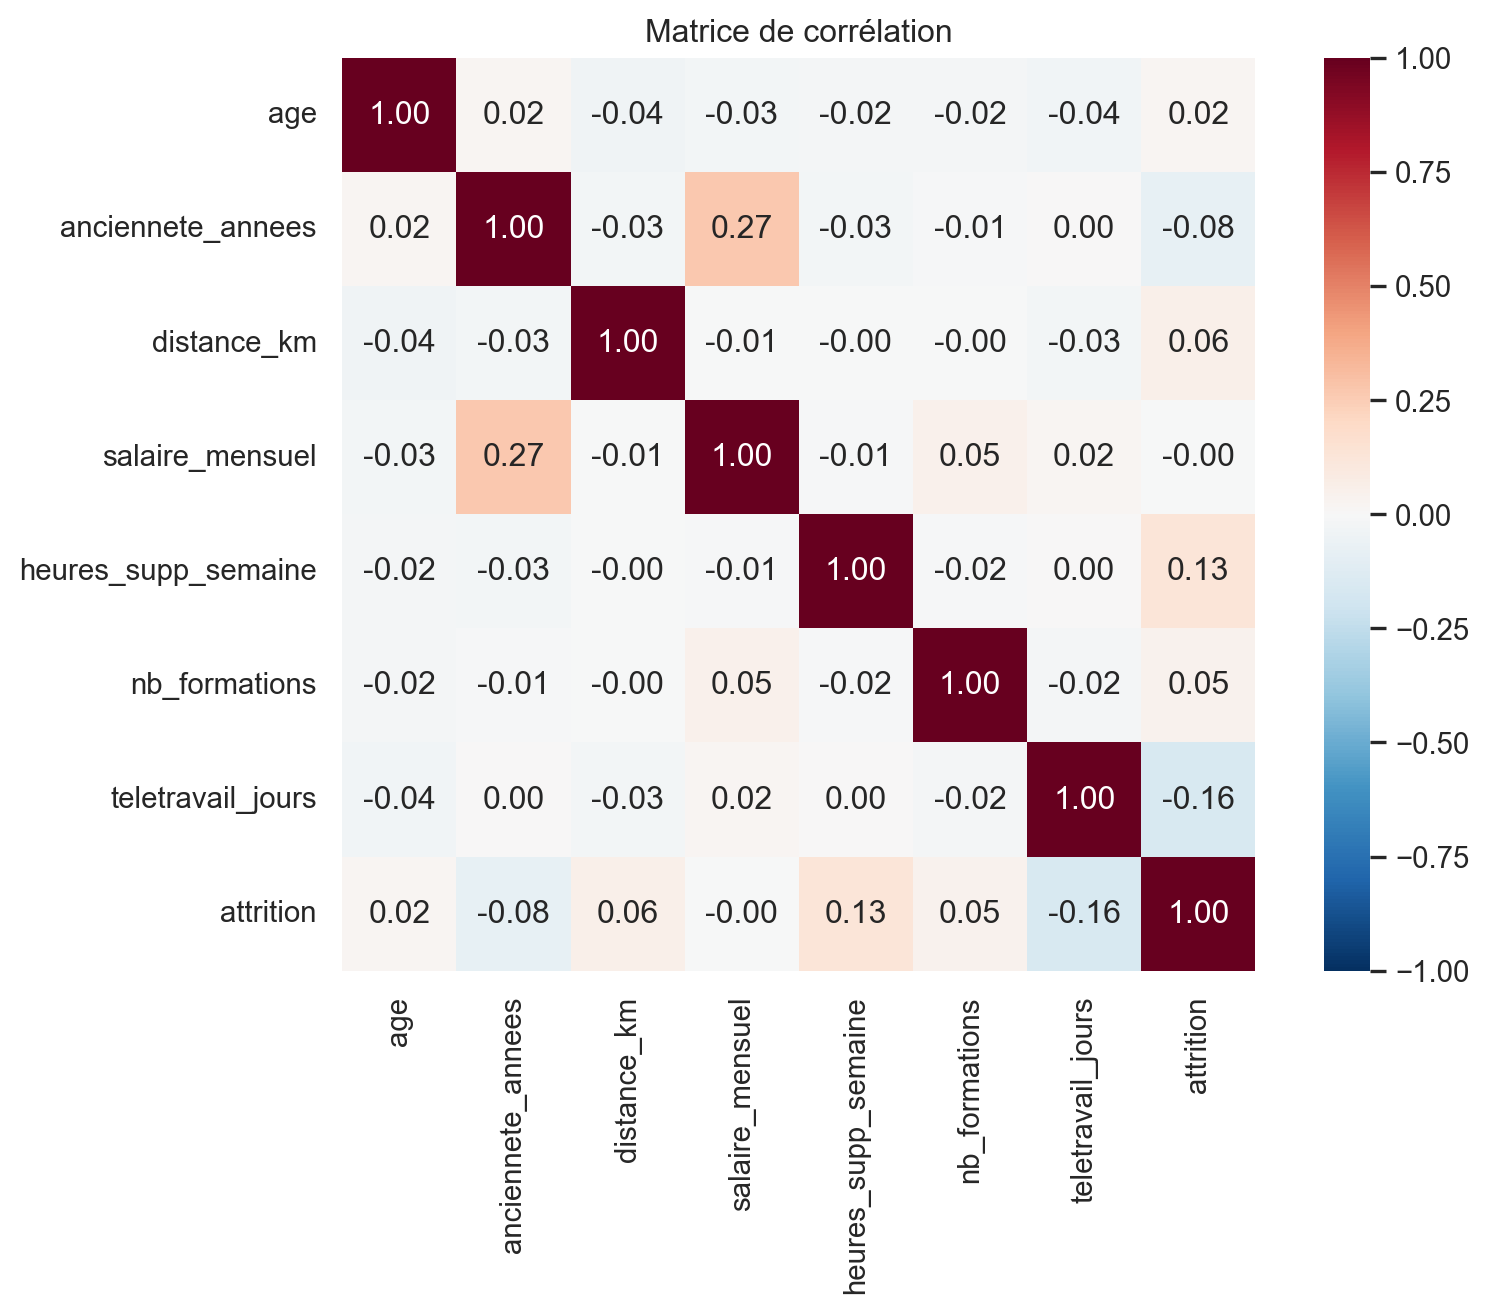


Corrélations avec attrition (triées) :
teletravail_jours     -0.158
heures_supp_semaine    0.128
anciennete_annees     -0.079
distance_km            0.061
nb_formations          0.046
age                    0.023
salaire_mensuel       -0.004
Name: attrition, dtype: float64


In [21]:
cols_num = ["age", "anciennete_annees", "distance_km", "salaire_mensuel",
            "heures_supp_semaine", "nb_formations", "teletravail_jours", "attrition"]

corr = df[cols_num].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            vmin=-1, vmax=1, square=True, ax=ax)
ax.set_title("Matrice de corrélation")
plt.tight_layout()
plt.show()

# Focus : corrélations avec attrition
print("\nCorrélations avec attrition (triées) :")
print(corr["attrition"].drop("attrition").sort_values(key=abs, ascending=False).round(3))

In [22]:
#| eval: false
# TODO: Étape 3.1

In [23]:
# Garder id_employe comme index (pratique pour retrouver les employés plus tard)
df_clean = df.set_index("id_employe")

# Supprimer les colonnes inutiles
cols_a_supprimer = ["nom_complet", "matricule_interne", "pays"]
df_clean = df_clean.drop(columns=cols_a_supprimer)

print(f"Colonnes restantes : {df_clean.shape[1]}")
print(df_clean.columns.tolist())

Colonnes restantes : 13
['age', 'genre', 'departement', 'niveau_etudes', 'anciennete_annees', 'distance_km', 'salaire_mensuel', 'heures_supp_semaine', 'satisfaction', 'nb_formations', 'teletravail_jours', 'date_embauche', 'attrition']


In [24]:
#| eval: false
# TODO: Étape 3.2

In [25]:
n_avant = len(df_clean)
df_clean = df_clean[~df_clean.index.duplicated(keep="first")]
# OU : df_clean = df_clean.reset_index().drop_duplicates().set_index("id_employe")
print(f"Avant : {n_avant}, Après : {len(df_clean)}")
print(f"Doublons supprimés : {n_avant - len(df_clean)}")

Avant : 1505, Après : 1500
Doublons supprimés : 5


In [26]:
#| eval: false
# TODO: Étape 3.3

In [27]:
print("Avant normalisation :")
print(df_clean["satisfaction"].value_counts(dropna=False))

Avant normalisation :
satisfaction
Satisfait           444
Neutre              424
Très satisfait      273
Insatisfait         225
Très insatisfait     69
NaN                  45
SATISFAIT            10
satisfait            10
Name: count, dtype: int64


In [28]:
# Normaliser : strip + title case
df_clean["satisfaction"] = df_clean["satisfaction"].astype(str).str.strip().str.title()
# Remettre les vrais NaN (qui ont été convertis en "Nan" par str)
df_clean.loc[df_clean["satisfaction"] == "Nan", "satisfaction"] = np.nan

print("Après normalisation :")
print(df_clean["satisfaction"].value_counts(dropna=False))

Après normalisation :
satisfaction
Satisfait           464
Neutre              424
Très Satisfait      273
Insatisfait         225
Très Insatisfait     69
NaN                  45
Name: count, dtype: int64


In [29]:
#| eval: false
# TODO: Étape 3.4

In [30]:
n_neg = (df_clean["anciennete_annees"] < 0).sum()
print(f"Valeurs négatives d'ancienneté : {n_neg}")

df_clean.loc[df_clean["anciennete_annees"] < 0, "anciennete_annees"] = 0
print(f"Min ancienneté : {df_clean['anciennete_annees'].min()}")

Valeurs négatives d'ancienneté : 3
Min ancienneté : 0.0


In [31]:
#| eval: false
# TODO: Étape 3.5

In [32]:
# 1. Outliers salaire (IQR)
q1 = df_clean["salaire_mensuel"].quantile(0.25)
q3 = df_clean["salaire_mensuel"].quantile(0.75)
iqr = q3 - q1
mask_out = (df_clean["salaire_mensuel"] < q1 - 1.5*iqr) | (df_clean["salaire_mensuel"] > q3 + 1.5*iqr)
print(f"Outliers salaire : {mask_out.sum()}")

df_clean.loc[mask_out, "salaire_mensuel"] = np.nan
print(f"Max salaire après : {df_clean['salaire_mensuel'].max():.0f} €")

Outliers salaire : 43
Max salaire après : 5492 €


In [33]:
# 2. Capping distance
n_out_dist = (df_clean["distance_km"] > 100).sum()
print(f"Distances > 100 km : {n_out_dist}")
df_clean["distance_km"] = df_clean["distance_km"].clip(upper=100)
print(f"Max distance après : {df_clean['distance_km'].max():.1f} km")

Distances > 100 km : 2
Max distance après : 100.0 km


In [34]:
#| eval: false
# TODO: Étape 3.6

In [35]:
# 1. salaire par niveau (MAR)
df_clean["salaire_mensuel"] = df_clean.groupby("niveau_etudes", observed=True)["salaire_mensuel"].transform(
    lambda x: x.fillna(x.median())
)

# 2. distance : médiane globale
df_clean["distance_km"] = df_clean["distance_km"].fillna(df_clean["distance_km"].median())

# 3. satisfaction : mode
df_clean["satisfaction"] = df_clean["satisfaction"].fillna(df_clean["satisfaction"].mode()[0])

# Vérification
print("NaN restants :")
print(df_clean.isna().sum()[df_clean.isna().sum() > 0])
print(f"\nTotal NaN : {df_clean.isna().sum().sum()}")

NaN restants :
Series([], dtype: int64)

Total NaN : 0


In [36]:
#| eval: false
# TODO: Étape 4.1

In [37]:
# Date
df_clean["date_embauche"] = pd.to_datetime(df_clean["date_embauche"])

# Nominales
df_clean["genre"] = df_clean["genre"].astype("category")
df_clean["departement"] = df_clean["departement"].astype("category")

# Ordinales
ordre_etudes = CategoricalDtype(
    categories=["Bac", "Licence", "Master", "Doctorat"],
    ordered=True
)
df_clean["niveau_etudes"] = df_clean["niveau_etudes"].astype(ordre_etudes)

ordre_satisfaction = CategoricalDtype(
    categories=["Très Insatisfait", "Insatisfait", "Neutre", "Satisfait", "Très Satisfait"],
    ordered=True
)
df_clean["satisfaction"] = df_clean["satisfaction"].astype(ordre_satisfaction)

print(df_clean.dtypes)

age                             int64
genre                        category
departement                  category
niveau_etudes                category
anciennete_annees             float64
distance_km                   float64
salaire_mensuel               float64
heures_supp_semaine           float64
satisfaction                 category
nb_formations                   int64
teletravail_jours               int64
date_embauche          datetime64[us]
attrition                       int64
dtype: object


In [38]:
#| eval: false
# TODO: Étape 4.2

In [39]:
df_clean["mois_embauche"] = df_clean["date_embauche"].dt.month
df_clean["trimestre_embauche"] = df_clean["date_embauche"].dt.quarter

# Encodage cyclique du mois
df_clean["mois_sin"] = np.sin(2 * np.pi * df_clean["mois_embauche"] / 12)
df_clean["mois_cos"] = np.cos(2 * np.pi * df_clean["mois_embauche"] / 12)

# Supprimer la date brute
df_clean = df_clean.drop(columns=["date_embauche"])

print(df_clean.columns.tolist())

['age', 'genre', 'departement', 'niveau_etudes', 'anciennete_annees', 'distance_km', 'salaire_mensuel', 'heures_supp_semaine', 'satisfaction', 'nb_formations', 'teletravail_jours', 'attrition', 'mois_embauche', 'trimestre_embauche', 'mois_sin', 'mois_cos']


In [40]:
#| eval: false
# TODO: Étape 4.3

In [41]:
# Définition des groupes de colonnes
cols_num_continues = ["age", "anciennete_annees", "distance_km", 
                      "salaire_mensuel", "heures_supp_semaine"]
cols_nominales = ["genre", "departement"]
cols_ordinales = ["niveau_etudes", "satisfaction"]
cols_passthrough = ["nb_formations", "teletravail_jours", "mois_sin", "mois_cos"]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), cols_num_continues),
        ("cat_nom", OneHotEncoder(sparse_output=False, handle_unknown="ignore"), cols_nominales),
        ("cat_ord", OrdinalEncoder(
            categories=[
                ["Bac", "Licence", "Master", "Doctorat"],
                ["Très Insatisfait", "Insatisfait", "Neutre", "Satisfait", "Très Satisfait"]
            ],
            handle_unknown="use_encoded_value",
            unknown_value=-1
        ), cols_ordinales),
        ("pass", "passthrough", cols_passthrough),
    ],
    remainder="drop",
    # On supprime les colonnes non listées (mois_embauche, trimestre_embauche qu'on garde pas)
)

print("✅ ColumnTransformer prêt")

✅ ColumnTransformer prêt


In [42]:
#| eval: false
# TODO: Étape 4.4

In [43]:
# 1. X et y
# On supprime les colonnes redondantes (mois_embauche déjà encodé en cyclique)
X = df_clean.drop(columns=["attrition", "mois_embauche", "trimestre_embauche"])
y = df_clean["attrition"]

print(f"X : {X.shape}")
print(f"y : {y.shape}")

X : (1500, 13)
y : (1500,)


In [44]:
# 2. Split stratifié
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Vérifier les proportions
print(f"y_train : {y_train.mean()*100:.2f}% d'attrition")
print(f"y_test  : {y_test.mean()*100:.2f}% d'attrition")

y_train : 10.75% d'attrition
y_test  : 10.67% d'attrition


In [45]:
# 4. Application du preprocessor
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# 5. Shapes et noms des features
print(f"X_train original  : {X_train.shape}")
print(f"X_train processed : {X_train_processed.shape}")

noms_features = preprocessor.get_feature_names_out()
print(f"\nFeatures créées ({len(noms_features)}) :")
for f in noms_features:
    print(f"  - {f}")

X_train original  : (1200, 13)
X_train processed : (1200, 20)

Features créées (20) :
  - num__age
  - num__anciennete_annees
  - num__distance_km
  - num__salaire_mensuel
  - num__heures_supp_semaine
  - cat_nom__genre_Autre
  - cat_nom__genre_F
  - cat_nom__genre_M
  - cat_nom__departement_IT
  - cat_nom__departement_Marketing
  - cat_nom__departement_Production
  - cat_nom__departement_R&D
  - cat_nom__departement_RH
  - cat_nom__departement_Ventes
  - cat_ord__niveau_etudes
  - cat_ord__satisfaction
  - pass__nb_formations
  - pass__teletravail_jours
  - pass__mois_sin
  - pass__mois_cos


In [46]:
#| eval: false
# TODO: Étape 4.5 — fonction réutilisable

In [47]:
def preparer_donnees_rh(df):
    """
    Pipeline de nettoyage et préparation des données RH.
    
    Retourne un DataFrame prêt à être consommé par le preprocessor sklearn.
    
    Paramètres
    ----------
    df : pd.DataFrame
        DataFrame brut issu de la source (mêmes colonnes que le CSV original).
    
    Retour
    ------
    df_clean : pd.DataFrame
        DataFrame nettoyé et prêt pour le ML.
    """
    df = df.copy()
    
    # 1. Set index + supprimer colonnes inutiles
    if "id_employe" in df.columns:
        df = df.set_index("id_employe")
    for col in ["nom_complet", "matricule_interne", "pays"]:
        if col in df.columns:
            df = df.drop(columns=col)
    
    # 2. Doublons
    df = df[~df.index.duplicated(keep="first")]
    
    # 3. Normaliser satisfaction
    df["satisfaction"] = df["satisfaction"].astype(str).str.strip().str.title()
    df.loc[df["satisfaction"] == "Nan", "satisfaction"] = np.nan
    
    # 4. Incohérences
    df.loc[df["anciennete_annees"] < 0, "anciennete_annees"] = 0
    
    # 5. Outliers
    q1, q3 = df["salaire_mensuel"].quantile([0.25, 0.75])
    iqr = q3 - q1
    mask_out = (df["salaire_mensuel"] < q1 - 1.5*iqr) | (df["salaire_mensuel"] > q3 + 1.5*iqr)
    df.loc[mask_out, "salaire_mensuel"] = np.nan
    df["distance_km"] = df["distance_km"].clip(upper=100)
    
    # 6. Imputation
    df["salaire_mensuel"] = df.groupby("niveau_etudes", observed=True)["salaire_mensuel"].transform(
        lambda x: x.fillna(x.median())
    )
    df["distance_km"] = df["distance_km"].fillna(df["distance_km"].median())
    df["satisfaction"] = df["satisfaction"].fillna(df["satisfaction"].mode()[0])
    
    # 7. Types
    df["date_embauche"] = pd.to_datetime(df["date_embauche"])
    df["genre"] = df["genre"].astype("category")
    df["departement"] = df["departement"].astype("category")
    df["niveau_etudes"] = df["niveau_etudes"].astype(
        CategoricalDtype(categories=["Bac", "Licence", "Master", "Doctorat"], ordered=True)
    )
    df["satisfaction"] = df["satisfaction"].astype(
        CategoricalDtype(
            categories=["Très Insatisfait", "Insatisfait", "Neutre", "Satisfait", "Très Satisfait"],
            ordered=True
        )
    )
    
    # 8. Features de date
    df["mois_sin"] = np.sin(2 * np.pi * df["date_embauche"].dt.month / 12)
    df["mois_cos"] = np.cos(2 * np.pi * df["date_embauche"].dt.month / 12)
    df = df.drop(columns=["date_embauche"])
    
    return df

# Test de la fonction
df_raw = pd.read_csv("ressources_tp/employes_rh.csv")
df_ready = preparer_donnees_rh(df_raw)

print(f"✅ Fonction testée : {df_raw.shape} → {df_ready.shape}")
print(f"NaN restants : {df_ready.isna().sum().sum()}")

✅ Fonction testée : (1505, 17) → (1500, 14)


NaN restants : 0
